In [ ]:
!pip install bertopic
!pip install sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.0/153.0 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 61.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 65.0 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu

In [ ]:
import pandas as pd
import numpy as np
from bertopic import BERTopic
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from collections import defaultdict
from sentence_transformers import SentenceTransformer

In [ ]:
# gunakan embedding model dari IndoBERT
embedding_model = SentenceTransformer("indobenchmark/indobert-base-p1")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
# import data
df = pd.read_csv('/content/result_2.csv')
df

# filter
df_filtered = df[df['title'] == 'RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO']
display(df_filtered)

,title,stars,text,bin_pelayanan,bin_fasilitas,predicted_labels_1,labels,prob_layanan,prob_fasilitas
1926,RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO,5,pelayanan top,1,0,['pelayanan'],positive,0.995726,0.003406
1927,RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO,5,kerenanak ke 2 lahir dengan selamat semua ibu ...,1,0,['pelayanan'],positive,0.997097,0.005579
1928,RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO,5,terima kasihhh banyak one day surgery saya suk...,1,0,['pelayanan'],positive,0.973308,0.196939
1929,RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO,5,cukup nyaman bagi pasien maupun keluarga pelay...,1,0,['pelayanan'],positive,0.999271,0.054692
1930,RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO,5,Layanan yang Baik Staf yang Baik,1,0,['pelayanan'],positive,0.997927,0.006413
...,...,...,...,...,...,...,...,...,...
4169,RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO,4,surtere ayu,1,1,"['pelayanan', 'fasilitas']",positive,0.975834,0.699392
4170,RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO,3,usus,0,0,[],negative,0.045810,0.124545
4171,RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO,4,semoga istriku cepet sembuh ya allah,1,0,['pelayanan'],positive,0.990860,0.004845
4172,RUMAH SAKIT Dr. OEN KANDANG SAPI SOLO,5,ramah kasirnya •°•ħєє• ħєє •ħєє•°•,1,0,['pelayanan'],positive,0.998248,0.013782


In [ ]:
# menghapus stopwords
import re

# daftar
stopwords = ['saya', 'yg', 'dan', 'yang', 'di', 'tidak', 'juga', 'utk', 'itu',
             'untuk', 'juga', 'jg', 'nya', 'tapi', 'tp', 'ga', 'gak', 'ngga', 'nggak', 'sy', 'lagi',
             'lg', 'dengan', 'dgn', 'dg', 'ini', 'kami', 'apa', 'ada', 'ke', 'ya', 'dong', 'sgt', 'bgt',
             'karena', 'krn', 'sebagai', 'sbg', 'dari', 'malah']

# function
def remove_stopwords(text):
    if isinstance(text, str):  # make sure string
        pattern = r'\b(?:' + '|'.join(stopwords) + r')\b'
        return re.sub(pattern, '', text, flags=re.IGNORECASE).strip()
    return text


df_filtered['text'] = df_filtered['text'].apply(remove_stopwords)

# Kategori

In [ ]:
# insialisasi model untuk dua kategori
layanan_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)
fasilitas_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=5)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan probabilitas kategori
def assign_reviews_by_category(data, threshold=0.5):
    layanan_reviews = []
    fasilitas_reviews = []
    layanan_indices = []
    fasilitas_indices = []
    for idx, row in data.iterrows():
        if row['prob_layanan'] >= threshold:
            layanan_reviews.append(row['text'])
            layanan_indices.append(idx)
        if row['prob_fasilitas'] >= threshold:
            fasilitas_reviews.append(row['text'])
            fasilitas_indices.append(idx)
    return layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices

# Memisahkan ulasan (ulasan dengan prob 0.99 masuk ke kedua kategori)
layanan_reviews, fasilitas_reviews, layanan_indices, fasilitas_indices = assign_reviews_by_category(df_filtered, threshold=0.5)

In [ ]:
# Pemodelan topik untuk kategori layanan
if layanan_reviews:
    topics_layanan, probs_layanan = layanan_model.fit_transform(layanan_reviews)
else:
    topics_layanan, probs_layanan = [], []

In [ ]:
# Pemodelan topik untuk kategori fasilitas
if fasilitas_reviews:
    topics_fasilitas, probs_fasilitas = fasilitas_model.fit_transform(fasilitas_reviews)
else:
    topics_fasilitas, probs_fasilitas = [], []

In [ ]:
# layanan_model.update_topics(layanan_reviews, top_n_words=10)  # Batasi ke 10 kata
# fasilitas_model.update_topics(fasilitas_reviews, top_n_words=10)  # Batasi ke 10 kata

## Hasil topic modelling

In [ ]:
# melihat total topic layanan
print(len(layanan_model.get_topics()))

# melihat total topic fasilitas
print(len(fasilitas_model.get_topics()))

5
5


In [ ]:
layanan_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,680,-1_sangat_pelayanan_ramah_dr,"[sangat, pelayanan, ramah, dr, rs, baik, oen, ...",[pelayanan dr oen kandang sapi ramah cepat me...
1,0,613,0_pelayanan_ramah_sangat_bagus,"[pelayanan, ramah, sangat, bagus, baik, memuas...","[pelayanan sangat bagus, pelayanan ramah bagu..."
2,1,563,1_dr_rs_pelayanan_dokter,"[dr, rs, pelayanan, dokter, pasien, oen, sakit...","[pelayanan rs dr oen baik bagus semua, pelaya..."
3,2,207,2_bagus_sangat_puas_memuaskan,"[bagus, sangat, puas, memuaskan, baik, cukup, ...","[sangat bagus, sangat bagus, sangat baik bagus]"
4,3,53,3_terima_kasih_atas_terimakasih,"[terima, kasih, atas, terimakasih, pelayananny...","[sangat baik pelayanannya terima kasih, terima..."


In [ ]:
fasilitas_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,34,-1_oke_biasa_puas_cukup,"[oke, biasa, puas, cukup, rekomended, sangat, ...","[Oke, Oke, Oke]"
1,0,593,0_pelayanan_ramah_sangat_bersih,"[pelayanan, ramah, sangat, bersih, baik, nyama...","[bersih pelayanan sangat baik, pelayanan bag..."
2,1,215,1_bagus_sangat_baik_memuaskan,"[bagus, sangat, baik, memuaskan, nyaman, puas,...","[sangat bagus, sangat bagus, sangat baik bagus]"
3,2,23,2_sakit_rumah_solo_terbaik,"[sakit, rumah, solo, terbaik, kota, salah, sat...","[Rumah Sakit Terbaik Kota, salah satu rumah s..."
4,3,13,3_terima_kasih_semuanya_terimakasih,"[terima, kasih, semuanya, terimakasih, mb, tri...","[terima kasih, Terima kasih, terima kasih]"


## Frekuensi sentimen dari setiap topik

In [ ]:
import numpy as np
import pandas as pd

# === Analisis Topik & Sentimen untuk Layanan ===
# Pastikan indeks valid
layanan_indices_valid = np.intersect1d(layanan_indices, df_filtered.index)

df_layanan = df_filtered.loc[layanan_indices_valid].copy()
df_layanan["topic"] = topics_layanan[:len(df_layanan)]  # pastikan panjang sama

df_layanan = df_layanan[df_layanan['topic'] != -1]
topic_sentiment_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'])
emotion_dist_layanan = pd.crosstab(df_layanan['topic'], df_layanan['labels'], normalize='index')

print("=== Distribusi Sentimen per Topik (Layanan) ===")
print(topic_sentiment_layanan)
print("\n=== Proporsi Sentimen per Topik (Layanan) ===")
print(emotion_dist_layanan)


# === Analisis Topik & Sentimen untuk Fasilitas ===
# Pastikan indeks valid
fasilitas_indices_valid = np.intersect1d(fasilitas_indices, df_filtered.index)

df_fasilitas = df_filtered.loc[fasilitas_indices_valid].copy()
df_fasilitas["topic"] = topics_fasilitas[:len(df_fasilitas)]  # pastikan panjang sama

df_fasilitas = df_fasilitas[df_fasilitas['topic'] != -1]
topic_sentiment_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'])
emotion_dist_fasilitas = pd.crosstab(df_fasilitas['topic'], df_fasilitas['labels'], normalize='index')

print("\n=== Distribusi Sentimen per Topik (Fasilitas) ===")
print(topic_sentiment_fasilitas)
print("\n=== Proporsi Sentimen per Topik (Fasilitas) ===")
print(emotion_dist_fasilitas)


=== Distribusi Sentimen per Topik (Layanan) ===
labels  negative  neutral  positive
topic                              
0             10        1       602
1            128       46       389
2             14        3       190
3              0        1        52

=== Proporsi Sentimen per Topik (Layanan) ===
labels  negative   neutral  positive
topic                               
0       0.016313  0.001631  0.982055
1       0.227353  0.081705  0.690941
2       0.067633  0.014493  0.917874
3       0.000000  0.018868  0.981132

=== Distribusi Sentimen per Topik (Fasilitas) ===
labels  negative  neutral  positive
topic                              
0             46       23       524
1             14        5       196
2              0       10        13
3              0        0        13

=== Proporsi Sentimen per Topik (Fasilitas) ===
labels  negative   neutral  positive
topic                               
0       0.077572  0.038786  0.883642
1       0.065116  0.023256  0.911628
2  

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

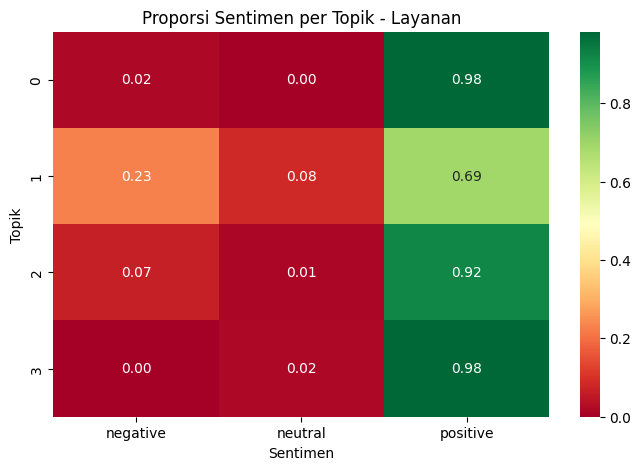

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_layanan, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Layanan")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

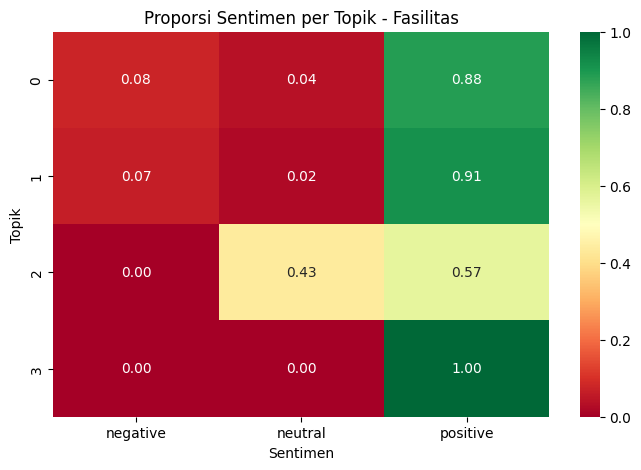

In [ ]:
# Heatmap proporsi (Layanan)
plt.figure(figsize=(8, 5))
sns.heatmap(emotion_dist_fasilitas, annot=True, fmt=".2f", cmap="RdYlGn")
plt.title("Proporsi Sentimen per Topik - Fasilitas")
plt.ylabel("Topik")
plt.xlabel("Sentimen")
plt.show()

In [ ]:
# Fungsi untuk menampilkan kata kunci tiap topik
def tampilkan_topik(model, kategori):
    topics = model.get_topics()
    print(f"=== Topik untuk kategori {kategori} ===")
    for topic_id, topic_info in topics.items():
        print(f"Topic {topic_id}:")
        print(f"Representasi: {topic_info}")
        print("-" * 50)
    print("\n")

# Panggil untuk layanan dan fasilitas
tampilkan_topik(layanan_model, "Layanan")
tampilkan_topik(fasilitas_model, "Fasilitas")

=== Topik untuk kategori Layanan ===
Topic -1:
Representasi: [('sangat', np.float64(0.062187840836440356)), ('pelayanan', np.float64(0.06178511659627164)), ('ramah', np.float64(0.05306601628581882)), ('dr', np.float64(0.05264639810061063)), ('rs', np.float64(0.04781033126424087)), ('baik', np.float64(0.04497670639740415)), ('oen', np.float64(0.04496496218929935)), ('dokter', np.float64(0.03987844411662378)), ('perawat', np.float64(0.0358491012628103)), ('kandang', np.float64(0.03303186970119169))]
--------------------------------------------------
Topic 0:
Representasi: [('pelayanan', np.float64(0.21626636820907305)), ('ramah', np.float64(0.16807134000755697)), ('sangat', np.float64(0.1664971023682299)), ('bagus', np.float64(0.15965726778927627)), ('baik', np.float64(0.12786244544962888)), ('memuaskan', np.float64(0.09546706166168448)), ('pelayanannya', np.float64(0.08641177053250242)), ('cepat', np.float64(0.08352350596095023)), ('bersih', np.float64(0.08254700975224263)), ('nyaman', 

# Sentimen

In [ ]:
# insialisasi model untuk dua sentimen
positive_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=8)
negative_model = BERTopic(embedding_model=embedding_model, min_topic_size=10, nr_topics=6)

In [ ]:
# Fungsi untuk memisahkan ulasan berdasarkan sentimen
def assign_reviews_by_sentiment(data):
    positif_reviews = data[data['labels'] == 'positive']['text'].tolist()
    negatif_reviews = data[data['labels'] == 'negative']['text'].tolist()
    positif_indices = data[data['labels'] == 'positive'].index.tolist()
    negatif_indices = data[data['labels'] == 'negative'].index.tolist()
    return positif_reviews, negatif_reviews, positif_indices, negatif_indices

In [ ]:
# Memisahkan ulasan berdasarkan sentimen
positif_reviews, negatif_reviews, positif_indices, negatif_indices = assign_reviews_by_sentiment(df_filtered)

In [ ]:
# Pemodelan topik untuk sentimen positif
if positif_reviews:
    topics_positif, probs_positif = positive_model.fit_transform(positif_reviews)
else:
    topics_positif, probs_positif = [], []

In [ ]:
# Pemodelan topik untuk sentimen negatif
if negatif_reviews:
    topics_negatif, probs_negatif = negative_model.fit_transform(negatif_reviews)
else:
    topics_negatif, probs_negatif = [], []

## Hasil Topic Modelling

In [ ]:
# melihat total topic positive
print(len(positive_model.get_topics()))

# melihat total topic negative
print(len(negative_model.get_topics()))

8
2


In [ ]:
positive_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,-1,612,-1_pelayanan_sangat_ramah_baik,"[pelayanan, sangat, ramah, baik, dr, oen, rs, ...",[pelayanan sangat baik memuaskan perawat ramah...
1,0,391,0_ramah_dokter_sangat_dr,"[ramah, dokter, sangat, dr, baik, rs, perawat,...",[puas layanan diberikan oleh rs dr oen kanda...
2,1,387,1_pelayanan_sangat_bagus_memuaskan,"[pelayanan, sangat, bagus, memuaskan, ramah, b...","[pelayanan sangat bagus, pelayanan sangat bag..."
3,2,211,2_bagus_sangat_puas_memuaskan,"[bagus, sangat, puas, memuaskan, baik, cukup, ...","[sangat bagus, sangat bagus, sangat baik bagus]"
4,3,164,3_pelayanan_rumah_sakit_rs,"[pelayanan, rumah, sakit, rs, oen, sangat, ram...","[rumah sakit pelayanan bagus, pelayanan rum..."
5,4,97,4_pelayanan_nyaman_cepat_bagus,"[pelayanan, nyaman, cepat, bagus, bersih, suda...","[pelayanan cepat, baik bersih nyaman, bagus p..."
6,5,46,5_terima_kasih_atas_terimakasih,"[terima, kasih, atas, terimakasih, pelayananny...","[terima kasih, terima kasih atas pelayanannya,..."
7,6,20,6_sukses_dr_oen_semakin,"[sukses, dr, oen, semakin, semoga, selalu, pua...","[puas layanan dr oen semoga semakin maju, alh..."


In [ ]:
negative_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,32,0_bangkrut_pelayanan_sangat_bagus,"[bangkrut, pelayanan, sangat, bagus, mahal, sa...","[bangkrut, bangkrut, nyaman sangat disayangka..."
1,1,180,1_pasien_dokter_jam_pelayanan,"[pasien, dokter, jam, pelayanan, sudah, dr, rs...",[sudah 3 tahun langganan rumah sakit sangat...


In [ ]:
# Panggil untuk layanan dan fasilitas
tampilkan_topik(positive_model, "Positif")
tampilkan_topik(negative_model, "Negatif")

=== Topik untuk kategori Positif ===
Topic -1:
Representasi: [('pelayanan', np.float64(0.057811548318316044)), ('sangat', np.float64(0.05734348495795219)), ('ramah', np.float64(0.05324563993093151)), ('baik', np.float64(0.04384972737425938)), ('dr', np.float64(0.04273883835254255)), ('oen', np.float64(0.04140691796620234)), ('rs', np.float64(0.036323278744996024)), ('sakit', np.float64(0.032971688938668794)), ('rumah', np.float64(0.032525838517116976)), ('perawat', np.float64(0.03246381396538475))]
--------------------------------------------------
Topic 0:
Representasi: [('ramah', np.float64(0.03720495241853776)), ('dokter', np.float64(0.03658760749652044)), ('sangat', np.float64(0.03493759248509362)), ('dr', np.float64(0.034677879835099026)), ('baik', np.float64(0.03429077020817566)), ('rs', np.float64(0.03323648938920602)), ('perawat', np.float64(0.029596987668370153)), ('pasien', np.float64(0.02918424262308084)), ('pelayanan', np.float64(0.029168980744313996)), ('oen', np.float64(0